# Cardiovascular Disease Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict whether a person has cardiovascular disease or not.

In [240]:
import pandas as pd
import numpy as np
CardiovascularData=pd.read_csv("C:/Users/Ankit Raut/Python ML/Python IVY Feb-2024 (1)/Python IVY Feb-2024/Python Datasets/Classification Datasets/My Projects/health_data_Cardio.csv",
                               encoding='latin')
print('Before deleting repeated rows ',CardiovascularData.shape)
CardiovascularData.drop_duplicates(inplace=True) 
print('After deleting repeated rows ',CardiovascularData.shape)
CardiovascularData.head()

Before deleting repeated rows  (70000, 14)
After deleting repeated rows  (70000, 14)


,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


## Rejected Useless Columns:['Unnamed: 0','id']

## Target Variable is cardio

<Axes: xlabel='cardio'>

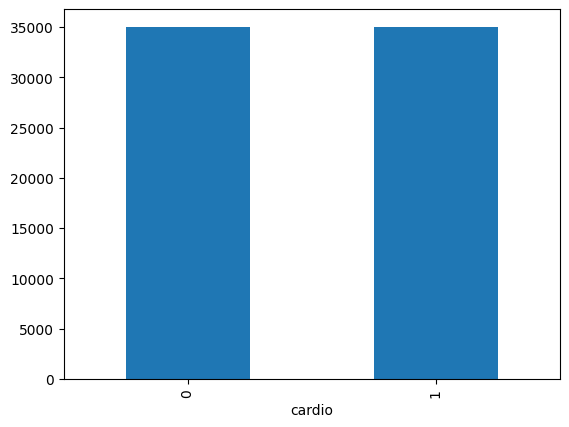

In [241]:
CardiovascularData.groupby('cardio').size().plot(kind='bar')

In [242]:
CardiovascularData.nunique()

Unnamed: 0     70000
id             70000
age             8076
gender             2
height           109
weight           287
ap_hi            153
ap_lo            157
cholesterol        3
gluc               3
smoke              2
alco               2
active             2
cardio             2
dtype: int64

In [243]:
CardiovascularData.columns

Index(['Unnamed: 0', 'id', 'age', 'gender', 'height', 'weight', 'ap_hi',
       'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

## CategoricalColumns:['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

## ContinousColumns:['age','height', 'weight', 'ap_hi', 'ap_lo']

In [244]:
CardiovascularData.drop(['Unnamed: 0','id'],axis=1,inplace=True)

In [245]:
CardiovascularData.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


In [246]:
CardiovascularData.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


In [247]:
CardiovascularData.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


IndexError: index 6 is out of bounds for axis 0 with size 6

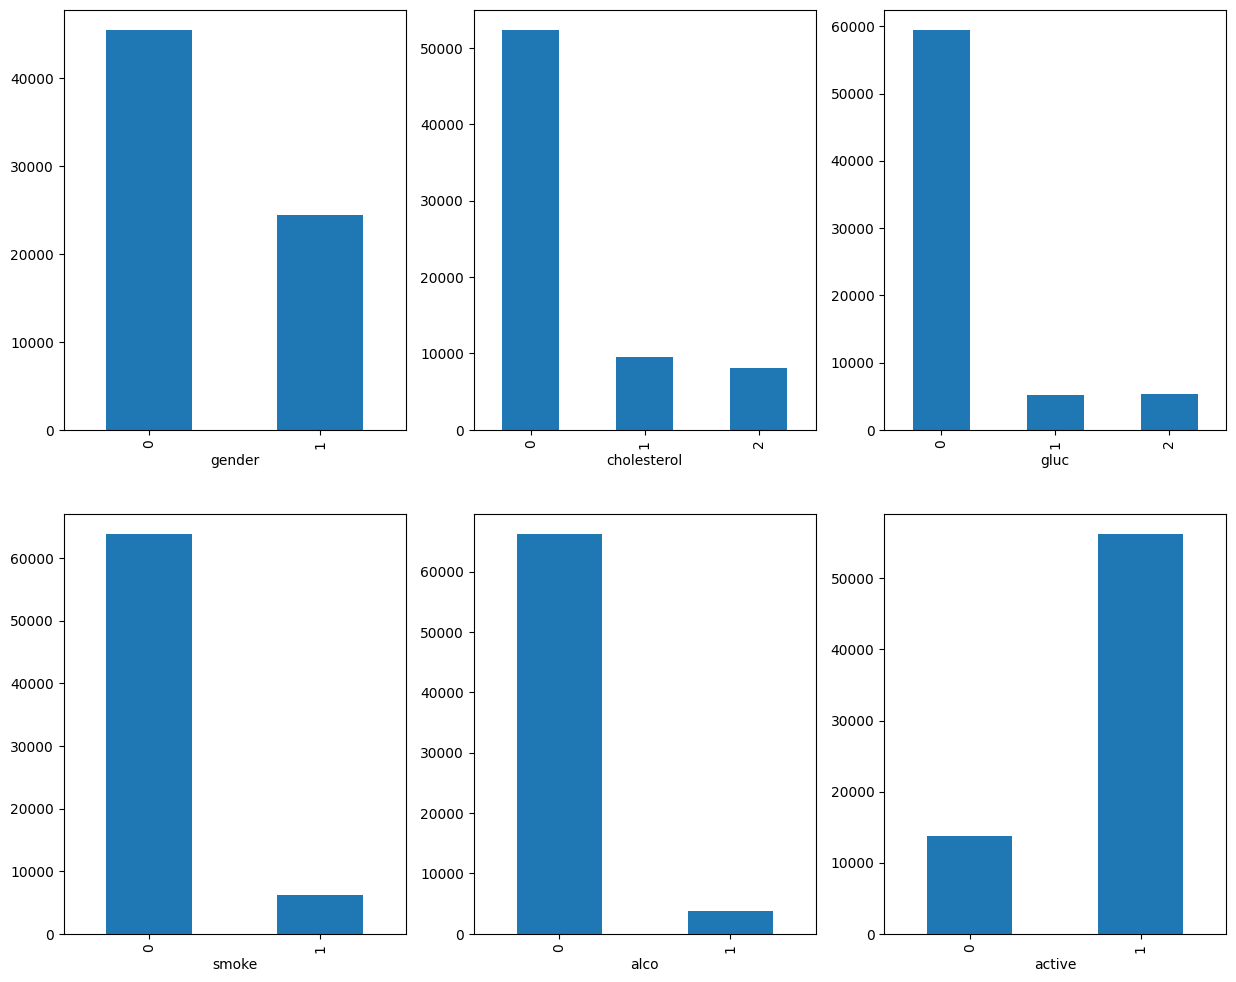

In [248]:
CategoricalColumns=['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    CardiovascularData.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'height'}>],
       [<Axes: title={'center': 'weight'}>,
        <Axes: title={'center': 'ap_hi'}>],
       [<Axes: title={'center': 'ap_lo'}>, <Axes: >]], dtype=object)

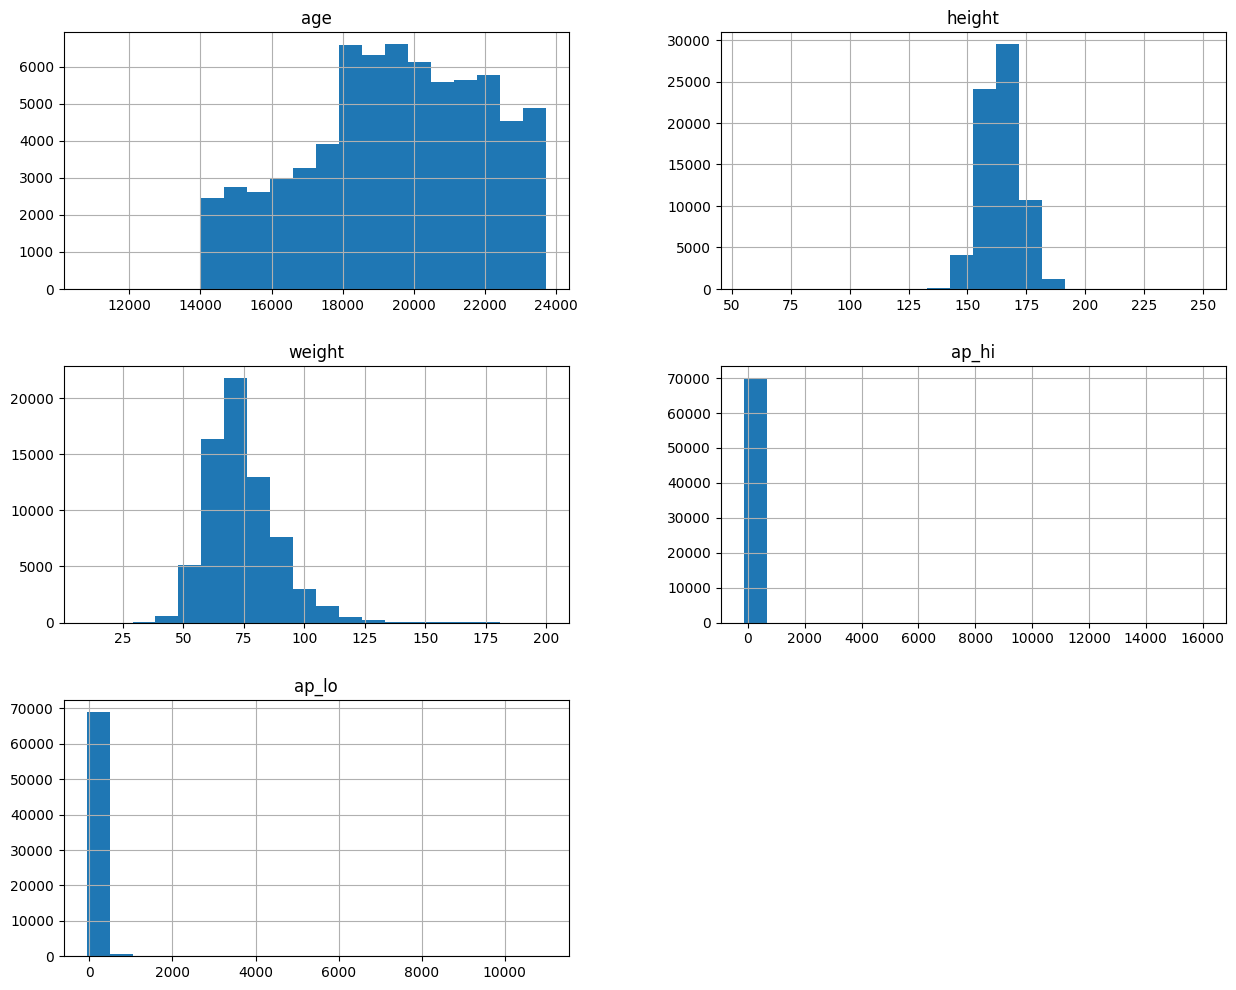

In [249]:
ContinousColumns=['age','height', 'weight', 'ap_hi', 'ap_lo']
CardiovascularData[ContinousColumns].hist(bins=20,figsize=(15,12))

## Can reject this cols:['ap_hi', 'ap_lo']

In [ ]:
CardiovascularData.isnull().sum()

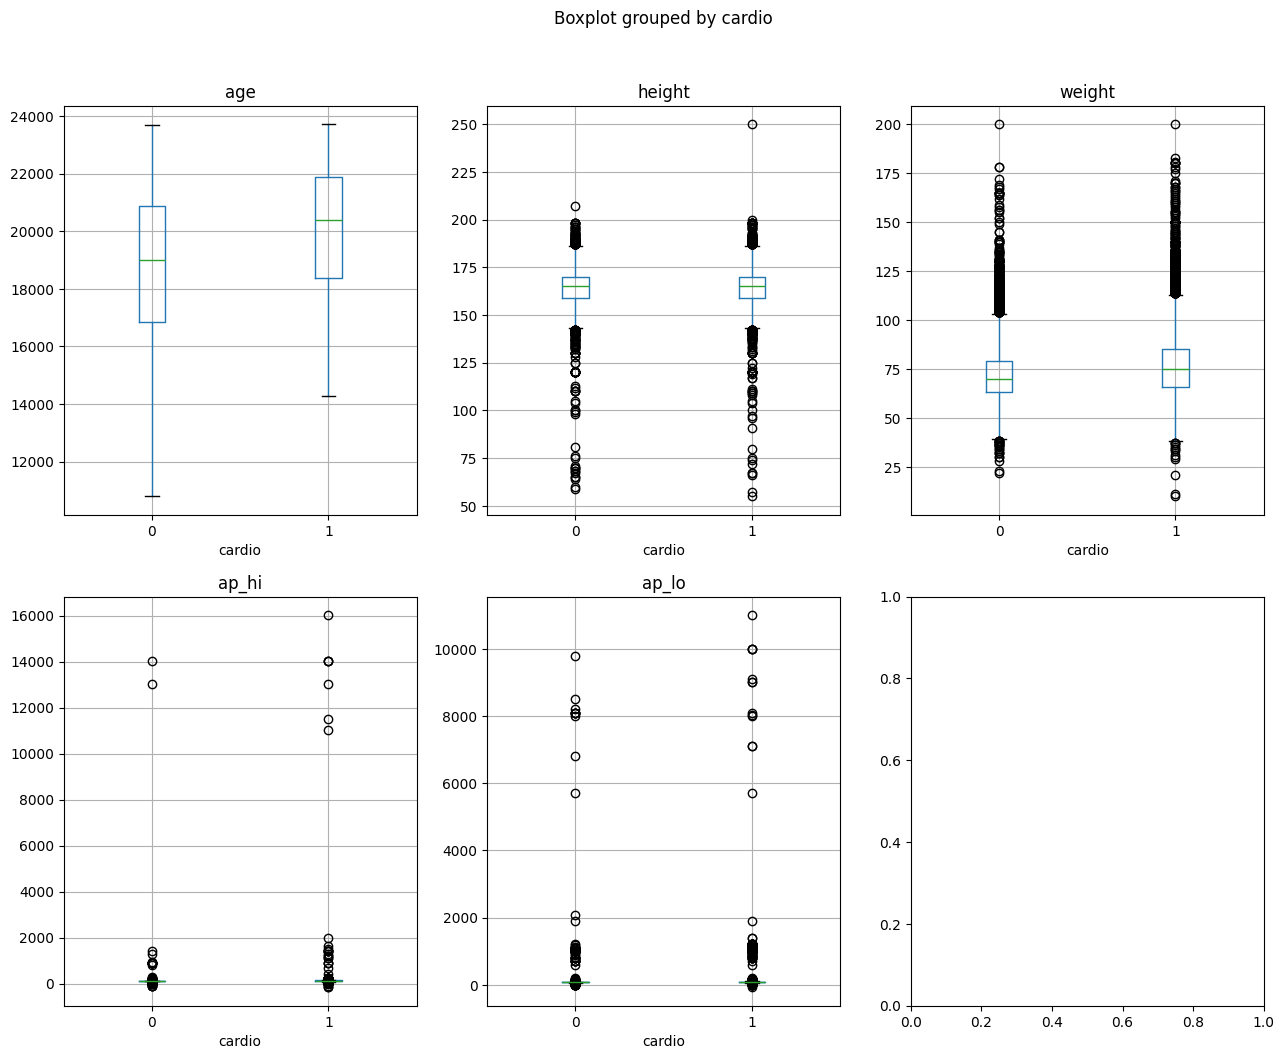

In [10]:
ContinousColumns=['age','height', 'weight', 'ap_hi', 'ap_lo']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(2,3,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(ContinousColumns,range(len(ContinousColumns))):
    CardiovascularData.boxplot(column=cols,by='cardio',ax=subplots[no_of_cols])
    

In [11]:
targetVariable='cardio'
inpData='CardiovascularData'
ContinousColumns=['age','height', 'weight', 'ap_hi', 'ap_lo']
def functionAnova(inpData,ContinousColumns,targetVariable):
    from scipy.stats import f_oneway
    SelectedPredictors=[]
    for cols in ContinousColumns:
        CategoricalGroupLists=inpData.groupby('cardio')[cols].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.05:
            print(cols,' is correlated with Cardio and P value is:',AnovaResults[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with Cardio and P value is:',AnovaResults[1])
    return (SelectedPredictors)  
functionAnova(CardiovascularData,ContinousColumns,targetVariable)

age  is correlated with Cardio and P value is: 0.0
height  is correlated with Cardio and P value is: 0.004196298813530794
weight  is correlated with Cardio and P value is: 0.0
ap_hi  is correlated with Cardio and P value is: 3.6980921262798253e-47
ap_lo  is correlated with Cardio and P value is: 7.424551292500745e-68


['age', 'height', 'weight', 'ap_hi', 'ap_lo']

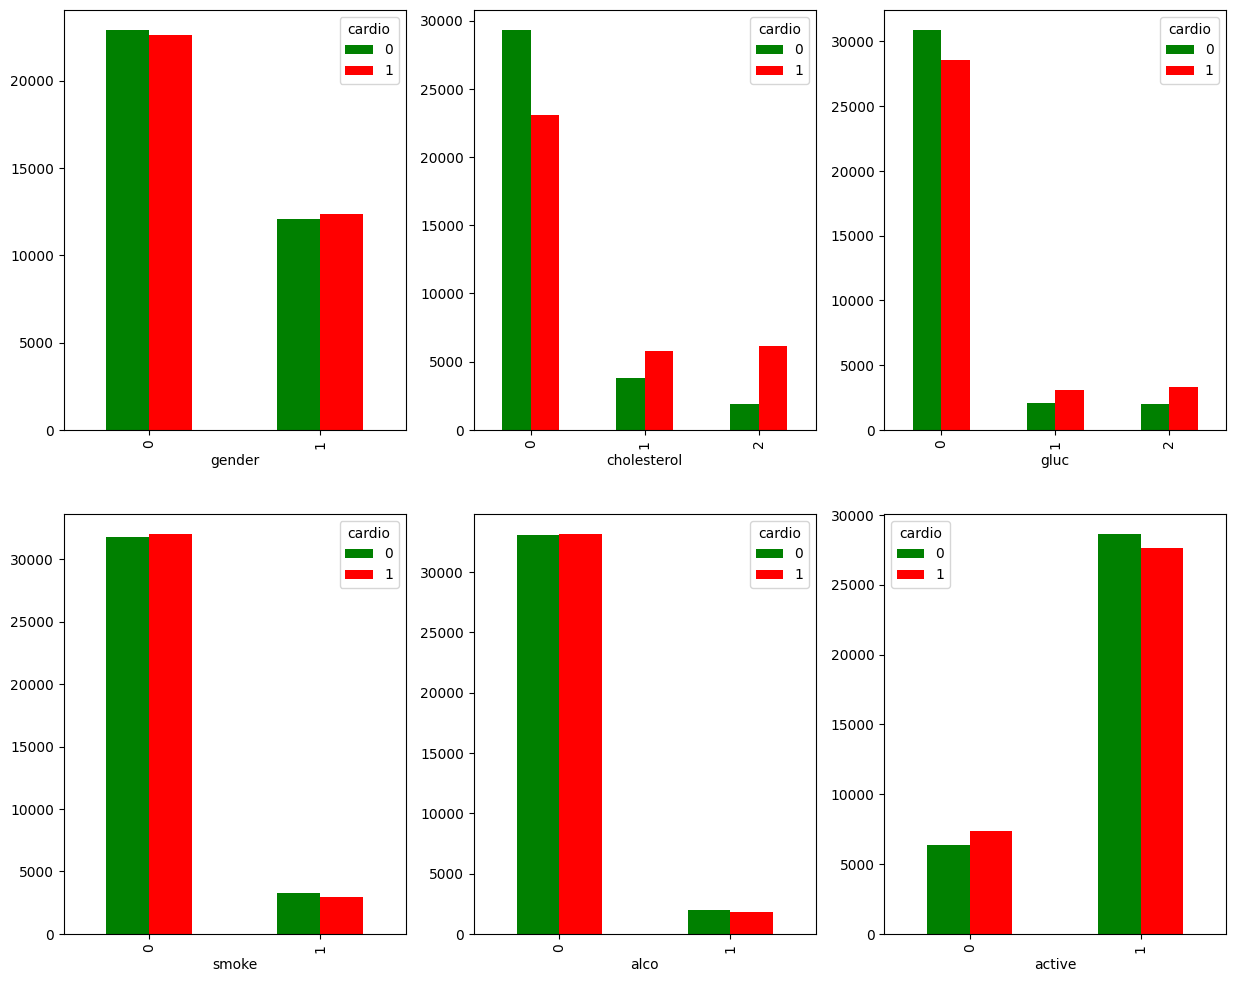

In [14]:
CategoricalColumns=['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(2,3,figsize=(15,12)) 
subplots=subplots.flatten()
for cols,no_of_cols in zip(CategoricalColumns,range(len(CategoricalColumns))):
    crosstabresults=pd.crosstab(columns=CardiovascularData['cardio'],index=CardiovascularData[cols])
    crosstabresults.plot.bar(color=['green','red'],ax=subplots[no_of_cols])

In [16]:
CategoricalColumns=['gender','cholesterol', 'gluc', 'smoke', 'alco', 'active']
targetVariable='cardio'
def Chi2_function(inpData,cols,targetVariable):
    SelectedPredictors=[]
    from scipy.stats import chi2_contingency
    for cols in CategoricalColumns:
        crosstabresults=pd.crosstab(columns=inpData['cardio'],index=inpData[cols])
        chi2_results=chi2_contingency(crosstabresults)
        if chi2_results[1]<0.05:
            print(cols,' is correlated with cardio and P values is:',chi2_results[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with cardio and P values is:',chi2_results[1])
    return SelectedPredictors
    
Chi2_function(CardiovascularData,cols,targetVariable) 
        


    

gender  is correlated with cardio and P values is: 0.03254570031936317
cholesterol  is correlated with cardio and P values is: 0.0
gluc  is correlated with cardio and P values is: 3.5786568357289105e-128
smoke  is correlated with cardio and P values is: 4.4293623605077656e-05
alco  is not correlated with cardio and P values is: 0.05452518218322108
active  is correlated with cardio and P values is: 4.3651927285329286e-21


['gender', 'cholesterol', 'gluc', 'smoke', 'active']

In [20]:
SelectedColumns=['gender', 'cholesterol', 'gluc', 'smoke', 'active','age', 'height', 'weight', 'ap_hi', 'ap_lo']
DataForMLCardiovascularData=CardiovascularData[SelectedColumns]
DataForMLCardiovascularData.to_pickle('CardiovascularData.pkl')
DataForMLCardiovascularData=pd.read_pickle('CardiovascularData.pkl')

DataForMLCardiovascularData['cardio']=CardiovascularData['cardio']
DataForMLCardiovascularData.head()

,gender,cholesterol,gluc,smoke,active,age,height,weight,ap_hi,ap_lo,cardio
0,1,0,0,0,1,18393.0,168.0,62.0,110.0,80.0,0
1,0,2,0,0,1,20228.0,156.0,85.0,140.0,90.0,1
2,0,2,0,0,0,18857.0,165.0,64.0,130.0,70.0,1
3,1,0,0,0,1,17623.0,169.0,82.0,150.0,100.0,1
4,0,0,0,0,0,17474.0,156.0,56.0,100.0,60.0,0


In [250]:
predictors=['gender', 'cholesterol', 'gluc', 'smoke', 'active','age', 'height', 'weight', 'ap_hi', 'ap_lo']
#predictors=[ 'cholesterol',  'age',   'ap_hi', ]
targetVariable='cardio'
X=DataForMLCardiovascularData[predictors].values
y=DataForMLCardiovascularData[targetVariable].values
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.16666,random_state=45)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(58333, 10)
(11667, 10)
(58333,)
(11667,)


In [23]:
X_train[0:4]

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        2.1840e+04, 1.7100e+02, 7.1000e+01, 1.2000e+02, 8.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        2.1415e+04, 1.6200e+02, 9.1000e+01, 1.2000e+02, 7.0000e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        2.2083e+04, 1.7000e+02, 7.7000e+01, 1.2000e+02, 8.0000e+01],
       [1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        2.2847e+04, 1.7100e+02, 6.5000e+01, 1.2000e+02, 8.0000e+01]])

In [22]:
y_train[0:4]

array([0, 0, 1, 0])

In [174]:
### Sandardization of data ###
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Choose either standardization or Normalization
# On this data Min Max Normalization produced better results

# Choose between standardization and MinMAx normalization
PredictorScaler=StandardScaler()
#PredictorScaler=MinMaxScaler()

# Storing the fit object for later reference
# Finding and storing Min and Max values for every column in X
PredictorScalerFit=PredictorScaler.fit(X)

# Generating the standardized values of X
X=PredictorScalerFit.transform(X)

# Split the data into training and testing set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1666, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(58338, 3)
(11662, 3)
(58338,)
(11662,)


In [182]:
X_train[0:4]

array([[    0., 21840.,   120.],
       [    0., 21415.,   120.],
       [    0., 22083.,   120.],
       [    0., 22847.,   120.]])

In [178]:
y_train[0:4]

array([1, 0, 0, 0])

In [253]:
from sklearn.linear_model import LogisticRegression
# choose different values for solver 'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=13,penalty='l2',solver='newton-cg')
LOG=clf.fit(X_train,y_train)
prediction =LOG.predict(X_test) 
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction, average='weighted')
print('Sample Test Accuracy:',np.round((F1_Score),2))
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Average Accuracy of the Model:',np.mean(AccuracyValues))

              precision    recall  f1-score   support

           0       0.71      0.77      0.74      5916
           1       0.74      0.67      0.70      5751

    accuracy                           0.72     11667
   macro avg       0.72      0.72      0.72     11667
weighted avg       0.72      0.72      0.72     11667

[[4548 1368]
 [1887 3864]]
Sample Test Accuracy: 0.72


C:\Users\Ankit Raut\anaconda3\Lib\site-packages\scipy\optimize\_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
C:\Users\Ankit Raut\anaconda3\Lib\site-packages\sklearn\utils\optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
C:\Users\Ankit Raut\anaconda3\Lib\site-packages\scipy\optimize\_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
C:\Users\Ankit Raut\anaconda3\Lib\site-packages\sklearn\utils\optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
C:\Users\Ankit Raut\anaconda3\Lib\site-packages\scipy\optimize\_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
C:\Users\Ankit Ra

[0.71351962 0.72419667 0.71692755 0.72715144 0.71641629]
Final Average Accuracy of the Model: 0.7196423139756558


              precision    recall  f1-score   support

           0       0.71      0.80      0.75      5916
           1       0.76      0.67      0.71      5751

    accuracy                           0.73     11667
   macro avg       0.74      0.73      0.73     11667
weighted avg       0.74      0.73      0.73     11667

[[4723 1193]
 [1915 3836]]
SampleDataAccuracy: 0.73
[0.72698561 0.7335716  0.73114435 0.72702811 0.73205314 0.72943233]
Final Average Accuracy of the Model: 0.730035857101206


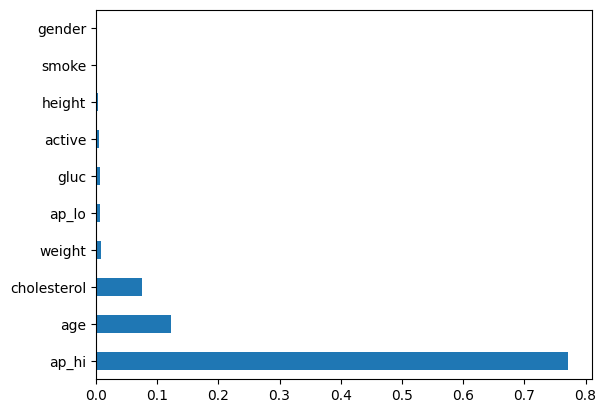

In [252]:
from sklearn import tree
clf=tree.DecisionTreeClassifier(max_depth=6,criterion='gini')
DTree=clf.fit(X,y)
prediction=DTree.predict(X_test)
feature_importances=pd.Series(DTree.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('SampleDataAccuracy:',np.round((F1_Score),2))
from sklearn.model_selection import cross_val_score
AccuracyValue=cross_val_score(DTree,X,y,cv=6,scoring='f1_weighted')
print(AccuracyValue) 
print('Final Average Accuracy of the Model:',np.mean(AccuracyValue))

# Selected Logistic Rgression Model for Deployment¶

## Deploying on Sample Production Data

In [223]:
NewData=pd.DataFrame(data=[[0,22000,110],
                           [1,23000,90],
                           [2,21000,71]], columns=predictors)
NewData

,cholesterol,age,ap_hi
0,0,22000,110
1,1,23000,90
2,2,21000,71


In [224]:
newX=NewData.values

In [225]:
DTree.predict(newX)

array([0, 0, 1])

In [216]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=DTree.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [226]:
GenerateSurvialPred(inpData=NewData)

,cholesterol,age,ap_hi,Prediction
0,0,22000,110,0
1,1,23000,90,0
2,2,21000,71,1
